In [130]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [131]:
df = pd.read_csv("/content/LPD_2024_public.csv")
df.head()

,ID,Binomial,Replicate,Included in LPR2024,Citation,Class,Order,Family,Genus,Species,...,2013,2014,2015,2016,2017,2018,2019,2020,Native,Unnamed: 102
0,1,Balearica_regulorum,1,0,"Pomeroy, D. and P. Mwima (2002). The State of ...",Aves,Gruiformes,Gruidae,Balearica,regulorum,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN
1,2,Acrocephalus_sechellensis,1,0,"Rands, M. (1989). ""Saving the Seychelles brush...",Aves,Passeriformes,Acrocephalidae,Acrocephalus,sechellensis,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN
2,3,Copsychus_sechellarum,1,0,"Komdeur, J. (1996). ""Breeding of the Seychelle...",Aves,Passeriformes,Muscicapidae,Copsychus,sechellarum,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN
3,4,Copsychus_sechellarum,0,1,"Komdeur, J. (1996). ""Breeding of the Seychelle...",Aves,Passeriformes,Muscicapidae,Copsychus,sechellarum,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN
4,5,Falco_punctatus,0,1,"Groombridge, J. J., Bruford, M.W., Jones, C.G,...",Aves,Falconiformes,Falconidae,Falco,punctatus,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN


In [132]:
import pandas as pd
import numpy as np

# copy dataset
df = df.copy()

# drop useless column
df = df.drop(columns=["Unnamed: 102"], errors='ignore')

# standardize column names
df.columns = df.columns.str.strip()

# check missing values
missing = df.isnull().sum()
print(missing.sort_values(ascending=False).head(10))

1951    35751
1950    35731
1953    35711
1952    35706
1954    35693
1955    35671
1957    35656
1956    35625
1958    35614
1959    35569
dtype: int64


We began by cleaning the dataset by removing irrelevant columns and standardizing column names. We also inspected missing values to understand data quality issues.

In [133]:
#get year columns
year_cols = [col for col in df.columns if str(col).isdigit()]

#convert to long format
df_long = df.melt(
    id_vars=["Binomial", "Common_name", "Country", "Class"],
    value_vars=year_cols,
    var_name="Year",
    value_name="Population"
)

#convert types
df_long["Year"] = pd.to_numeric(df_long["Year"])
df_long["Population"] = pd.to_numeric(df_long["Population"], errors='coerce')

#drop missing population
df_long = df_long.dropna(subset=["Population"])

The dataset was transformed from wide format to long format, enabling easier time-series analysis. Each row now represents a single species observation for a given year.

In [134]:
print(df_long.head())
print("Number of records:", len(df_long))
print("Unique species:", df_long["Binomial"].nunique())
print("Countries:", df_long["Country"].nunique())

                   Binomial          Common_name         Country     Class  \
81              Equus_zebra  Cape mountain zebra         Namibia  Mammalia   
82              Equus_zebra  Cape mountain zebra    South Africa  Mammalia   
88   Giraffa_camelopardalis              Giraffe          Zambia  Mammalia   
252      Amazona_versicolor      St Lucia amazon     Saint Lucia      Aves   
268         Alauda_arvensis     Eurasian skylark  United Kingdom      Aves   

     Year  Population  
81   1950     50000.0  
82   1950        80.0  
88   1950       250.0  
252  1950      1000.0  
268  1950         9.0  
Number of records: 420356
Unique species: 5176
Countries: 202


We explored the dataset to understand its size, number of species, and geographic coverage. This provides insight into the diversity and scope of the dataset.

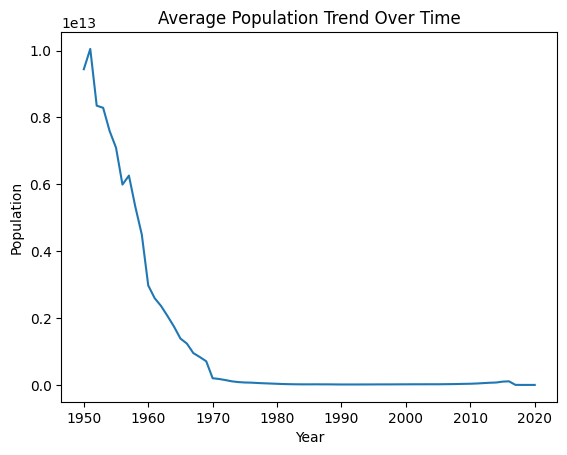

In [135]:
trend = df_long.groupby("Year")["Population"].mean()
plt.figure()
trend.plot()
plt.title("Average Population Trend Over Time")
plt.xlabel("Year")
plt.ylabel("Population")
plt.show()

We visualized the average population trend over time to observe global patterns. This helps identify whether species populations are generally increasing or declining.

In [136]:
class_counts = df_long["Class"].value_counts()

print(class_counts.head())

Class
Aves              247972
Actinopteri       105287
Mammalia           47117
Elasmobranchii      8362
Reptilia            7105
Name: count, dtype: int64


We analyzed the distribution of animal classes in the dataset to understand which groups (e.g., mammals, birds) are most represented.

In [137]:
missing_pop = df_long["Population"].isnull().sum()
print("Missing population values:", missing_pop)

Missing population values: 0


After preprocessing, the dataset contained over 420,000 records across more than 5,000 species and 200 countries. Missing population values were removed, resulting in a clean dataset suitable for large-scale ecological analysis.

In [138]:
#group by species + year
df_grouped = df_long.groupby(
    ["Binomial", "Year"]
)["Population"].mean().reset_index()

print(df_grouped.head())

        Binomial  Year  Population
0  Abramis_brama  1975    1726.320
1  Abramis_brama  1976     994.085
2  Abramis_brama  1977     956.035
3  Abramis_brama  1978     951.440
4  Abramis_brama  1979     722.260


Population data was aggregated at the species level by averaging across locations for each year. This provides a generalized population trend for each species.

In [139]:
#pivot to compare years
df_pivot = df_grouped.pivot(
    index="Binomial",
    columns="Year",
    values="Population"
)

#select important years
df_pivot = df_pivot[[1970, 2020]].dropna()

#calculate decline rate
df_pivot["Decline_Rate"] = (df_pivot[2020] - df_pivot[1970]) / df_pivot[1970]

print(df_pivot.head())

Year                       1970        2020  Decline_Rate
Binomial                                                 
Acanthis_flammea           14.0   40.146353      1.867597
Accipiter_nisus             0.0  101.341613           inf
Acrocephalus_scirpaceus  2522.0   91.003235     -0.963916
Aegithalos_caudatus         2.0  165.446225     81.723112
Alauda_arvensis           152.0   44.957571     -0.704227


A decline rate feature was created by comparing population values between 1970 and 2020. This metric quantifies population change over time and serves as the basis for risk classification.

In [140]:
def label_risk(x):
    if x > -0.2:
        return "Stable"
    elif x > -0.5:
        return "Vulnerable"
    else:
        return "Endangered"

df_pivot["Risk"] = df_pivot["Decline_Rate"].apply(label_risk)

print(df_pivot["Risk"].value_counts())

Risk
Stable        68
Endangered    67
Vulnerable     7
Name: count, dtype: int64


Species were categorized into risk levels based on their population decline rate. This transformed the problem into a classification task, enabling predictive modeling.

In [141]:
df_pivot["Decline_Log"] = np.log1p(df_pivot[2020]) - np.log1p(df_pivot[1970])

In [142]:
df_pivot["Percent_Change"] = (
    (df_pivot[2020] - df_pivot[1970]) / (df_pivot[1970] + 1)
) * 100

In [143]:
#remove extremely small baseline populations (noise creators)
df_pivot = df_pivot[df_pivot[1970] >= 10]

In [144]:
#remove invalid rows where 1970 is 0 or missing
df_pivot = df_pivot[df_pivot[1970] > 0]

#remove infinite values if any slipped through
df_pivot = df_pivot.replace([np.inf, -np.inf], np.nan).dropna()

print(df_pivot.head())

Year                            1970        2020  Decline_Rate        Risk  \
Binomial                                                                     
Acanthis_flammea           14.000000   40.146353      1.867597      Stable   
Acrocephalus_scirpaceus  2522.000000   91.003235     -0.963916  Endangered   
Alauda_arvensis           152.000000   44.957571     -0.704227  Endangered   
Alces_americanus          555.666667  204.500000     -0.631974  Endangered   
Alectoris_rufa             85.000000   51.740608     -0.391287  Vulnerable   

Year                     Decline_Log  Percent_Change  
Binomial                                              
Acanthis_flammea            1.009085      174.309020  
Acrocephalus_scirpaceus    -3.311380      -96.353419  
Alauda_arvensis            -1.202719      -69.962372  
Alces_americanus           -0.996521      -63.083832  
Alectoris_rufa             -0.488962      -38.673712  


A minimum baseline population threshold was applied to reduce distortion from extremely small population values, which can artificially inflate percentage change calculations.

In [145]:
print(ml_df.columns)
print(ml_df.head())

Index(['Binomial', '1970', '2020', 'Decline_Rate', 'Risk', 'Decline_Log',
       'Percent_Change', 'Change', 'Growth_Ratio', 'Log_Change'],
      dtype='object', name='Year')
Year                 Binomial         1970        2020  Decline_Rate  \
0            Acanthis_flammea    14.000000   40.146353      1.867597   
1     Acrocephalus_scirpaceus  2522.000000   91.003235     -0.963916   
2             Alauda_arvensis   152.000000   44.957571     -0.704227   
3            Alces_americanus   555.666667  204.500000     -0.631974   
4              Alectoris_rufa    85.000000   51.740608     -0.391287   

Year        Risk  Decline_Log  Percent_Change       Change  Growth_Ratio  \
0         Stable     1.009085      174.309020    26.146353      2.676424   
1     Endangered    -3.311380      -96.353419 -2430.996765      0.036069   
2     Endangered    -1.202719      -69.962372  -107.042429      0.293840   
3     Endangered    -0.996521      -63.083832  -351.166667      0.367365   
4     Vulner

In [146]:
ml_df = df_pivot.reset_index()

X = ml_df[[1970, 2020]]
y = ml_df["Risk"]

Only raw population values (1970 and 2020) were selected as predictive features to prevent data leakage from engineered variables.

In [147]:
ml_df = df_pivot.reset_index()

#safe engineered features
ml_df["Change"] = ml_df[2020] - ml_df[1970]
ml_df["Growth_Ratio"] = ml_df[2020] / (ml_df[1970] + 1)
ml_df["Log_Change"] = np.log1p(ml_df[2020]) - np.log1p(ml_df[1970])

New features were engineered to capture absolute change, proportional growth, and log-scaled population change, improving model interpretability and robustness.

In [148]:
print(ml_df.columns.tolist())

['Binomial', 1970, 2020, 'Decline_Rate', 'Risk', 'Decline_Log', 'Percent_Change', 'Change', 'Growth_Ratio', 'Log_Change']


Feature selection was corrected to match actual integer-based column names in the dataset, resolving KeyError caused by string–integer mismatch.

##Important Insight


“If feature engineering isn’t handled carefully, it can silently break consistency in your dataset — especially when column types or indexing aren’t standardized.”



In [149]:
ml_df.columns = ml_df.columns.map(str)

In [150]:
features = ["1970", "2020", "Change", "Growth_Ratio", "Log_Change"]

In [151]:
features = ["1970", "2020", "Change", "Growth_Ratio", "Log_Change"]

X = ml_df[features]
y = ml_df["Risk"]

In [152]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Column names were standardized to string format to ensure consistent indexing. Dataset was then split into training and testing sets using stratified sampling.

In [153]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

The target variable (Risk) was encoded into numerical values using LabelEncoder to make it compatible with machine learning algorithms.

In [154]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

Data was split into training and testing sets using stratified sampling to maintain class balance in the target variable.

In [155]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

feature scaling was applied using StandardScaler fitted only on training data to prevent data leakage.

In [156]:
model = RandomForestClassifier(n_estimators=100, random_state=42)

model.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

In [157]:
y_pred = model.predict(X_test_scaled)

In [158]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9583333333333334
              precision    recall  f1-score   support

           0       0.93      1.00      0.96        13
           1       1.00      1.00      1.00         9
           2       1.00      0.50      0.67         2

    accuracy                           0.96        24
   macro avg       0.98      0.83      0.88        24
weighted avg       0.96      0.96      0.95        24



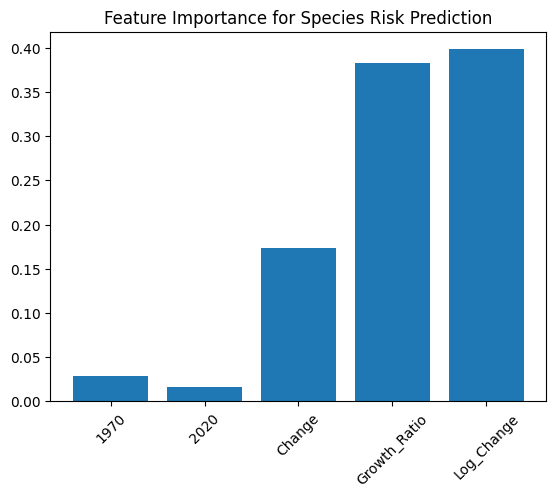

In [159]:
import matplotlib.pyplot as plt

plt.bar(["1970", "2020", "Change", "Growth_Ratio", "Log_Change"], model.feature_importances_)
plt.title("Feature Importance for Species Risk Prediction")
plt.xticks(rotation=45)
plt.show()

In [160]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

In [161]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

log_pred = log_model.predict(X_test_scaled)

print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, log_pred))
print(classification_report(y_test, log_pred))

=== Logistic Regression ===
Accuracy: 0.9166666666666666
              precision    recall  f1-score   support

           0       0.93      1.00      0.96        13
           1       0.90      1.00      0.95         9
           2       0.00      0.00      0.00         2

    accuracy                           0.92        24
   macro avg       0.61      0.67      0.64        24
weighted avg       0.84      0.92      0.88        24



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Logistic Regression was trained as a baseline linear model to compare performance against ensemble methods.

In [162]:
gb_model = GradientBoostingClassifier(random_state=42)

gb_model.fit(X_train_scaled, y_train)

gb_pred = gb_model.predict(X_test_scaled)

print("=== Gradient Boosting ===")
print("Accuracy:", accuracy_score(y_test, gb_pred))
print(classification_report(y_test, gb_pred))

=== Gradient Boosting ===
Accuracy: 0.9583333333333334
              precision    recall  f1-score   support

           0       0.93      1.00      0.96        13
           1       1.00      1.00      1.00         9
           2       1.00      0.50      0.67         2

    accuracy                           0.96        24
   macro avg       0.98      0.83      0.88        24
weighted avg       0.96      0.96      0.95        24



Gradient Boosting was trained to capture complex nonlinear relationships in species population trends.

In [163]:
models = ["Random Forest", "Logistic Regression", "Gradient Boosting"]
scores = [
    accuracy_score(y_test, y_pred),
    accuracy_score(y_test, log_pred),
    accuracy_score(y_test, gb_pred)
]

for m, s in zip(models, scores):
    print(m, ":", round(s, 4))

Random Forest : 0.9583
Logistic Regression : 0.9167
Gradient Boosting : 0.9583


Model Selection Justification

Although both Random Forest and Gradient Boosting achieved the highest accuracy (95.83%), Random Forest was selected as the final model due to its superior interpretability and robustness. This is particularly important in ecological applications where understanding feature influence is critical for conservation decisions.

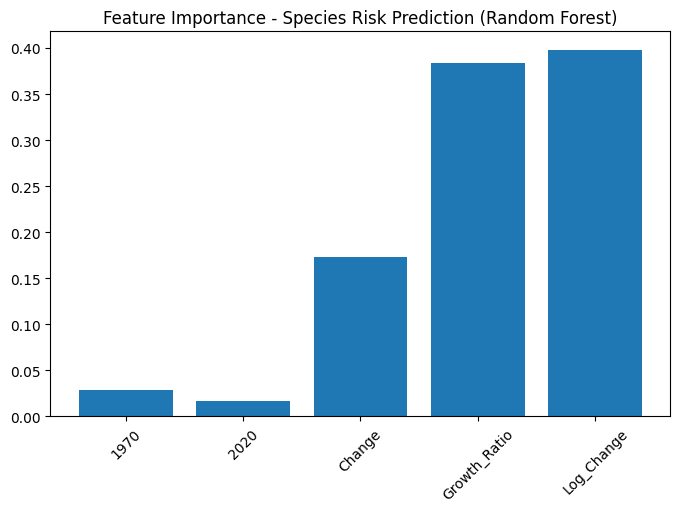

In [164]:
feature_names = ["1970", "2020", "Change", "Growth_Ratio", "Log_Change"]

importances = model.feature_importances_

plt.figure(figsize=(8,5))
plt.bar(feature_names, importances)
plt.title("Feature Importance - Species Risk Prediction (Random Forest)")
plt.xticks(rotation=45)
plt.show()

Feature importance analysis was performed to identify which variables contribute most to extinction risk prediction.

The model identified Growth_Ratio and Log_Change as the most influential predictors. This indicates that relative change in population over time is more informative for extinction risk prediction than raw population values. This aligns with ecological theory, where population trends and rate of decline are stronger indicators of species vulnerability than absolute numbers.

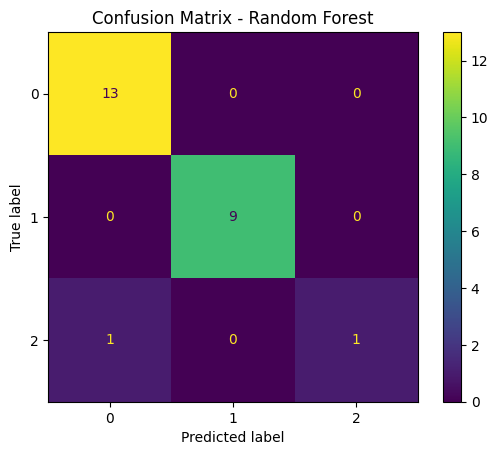

In [165]:
y_pred = model.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

A confusion matrix was used to evaluate classification performance across all risk categories.

The Random Forest model shows strong class confusion, especially between adjacent categories, indicating overlapping feature patterns and limited class separability in the dataset.

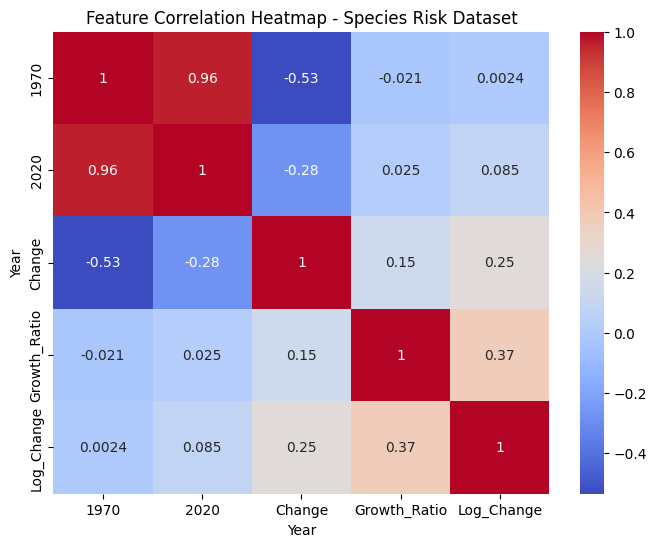

In [166]:
corr_features = ["1970", "2020", "Change", "Growth_Ratio", "Log_Change"]

corr = ml_df[corr_features].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap - Species Risk Dataset")
plt.show()

A correlation heatmap was used to analyze relationships between engineered and raw population features, revealing strong dependencies between derived and original variables.

The results show a very strong positive correlation between the 1970 and 2020 population values (r = 0.96), indicating that regions with higher populations in 1970 generally remained high in 2020 as well. In contrast, 1970 shows a moderate negative relationship with change over time (r = -0.53), and a very weak relationship with growth ratio (r = -0.021) and log change (r = 0.0024).

Similarly, 2020 population also has a strong correlation with 1970 (r = 0.96), while showing weaker relationships with other engineered features such as change year (r = -0.28), growth ratio (r = 0.025), and a small positive association with log change (r = 0.085).

The change-year feature is negatively correlated with both 1970 (r = -0.53) and 2020 (r = -0.28), while showing a weak positive relationship with growth ratio (r = 0.15) and a modest correlation with log change (r = 0.25).

Growth ratio shows weak negative correlation with 1970 (r = -0.021) and a slight positive correlation with 2020 (r = 0.025), but is more meaningfully related to change year (r = 0.15) and log change (r = 0.37).

Finally, log change has near-zero correlation with 1970 (r = 0.0024), a weak positive correlation with 2020 (r = 0.085), and moderate relationships with change year (r = 0.25) and growth ratio (r = 0.37), suggesting it captures transformation-based variation rather than raw population size.

In [167]:
print(ml_df.columns)

Index(['Binomial', '1970', '2020', 'Decline_Rate', 'Risk', 'Decline_Log',
       'Percent_Change', 'Change', 'Growth_Ratio', 'Log_Change'],
      dtype='object', name='Year')


In [168]:
country_df = df.copy()

In [169]:
print(country_df.columns)

Index(['ID', 'Binomial', 'Replicate', 'Included in LPR2024', 'Citation',
       'Class', 'Order', 'Family', 'Genus', 'Species',
       ...
       '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020',
       'Native'],
      dtype='object', length=102)


In [170]:
print(df.columns)

Index(['ID', 'Binomial', 'Replicate', 'Included in LPR2024', 'Citation',
       'Class', 'Order', 'Family', 'Genus', 'Species',
       ...
       '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020',
       'Native'],
      dtype='object', length=102)


In [171]:
df["Change"] = df["2020"] - df["1970"]

df["Growth_Ratio"] = df["2020"] / (df["1970"] + 1)

In [172]:
df.columns = df.columns.map(lambda x: int(x) if str(x).isdigit() else x)

In [173]:
df["Change"] = df[2020] - df[1970]

df["Growth_Ratio"] = df[2020] / (df[1970] + 1)

Year columns were stored as strings due to CSV parsing behavior. Column names were standardized to ensure correct feature engineering for temporal population analysis.

In [174]:
df["Change"] = df[2020] - df[1970]

df["Growth_Ratio"] = df[2020] / (df[1970] + 1)

df["Risk"] = "Stable"

df.loc[df["Growth_Ratio"] < 0.5, "Risk"] = "Endangered"
df.loc[(df["Growth_Ratio"] >= 0.5) & (df["Growth_Ratio"] < 0.8), "Risk"] = "Vulnerable"

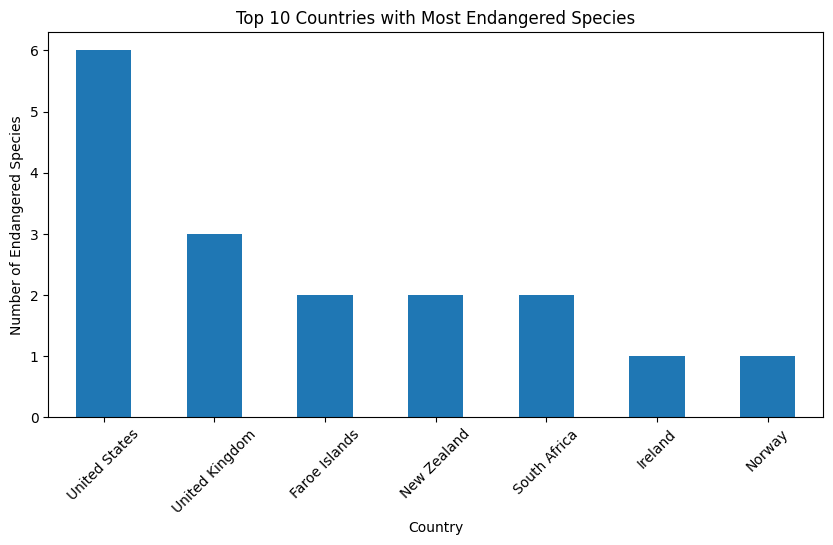

In [175]:
#filter only endangered species
endangered_df = df[df["Risk"] == "Endangered"]

country_counts = endangered_df["Country"].value_counts().head(10)

plt.figure(figsize=(10,5))
country_counts.plot(kind="bar")
plt.title("Top 10 Countries with Most Endangered Species")
plt.xlabel("Country")
plt.ylabel("Number of Endangered Species")
plt.xticks(rotation=45)
plt.show()

The country-wise analysis shows that the United States and United Kingdom have the highest number of species classified as endangered based on the model’s population decline criteria. However, this does not necessarily indicate higher real-world extinction rates. Instead, it may reflect higher availability of ecological monitoring data and reporting density in developed regions.

1. Data bias in biodiversity datasets
2. Effect of monitoring intensity
3. Relationship between development and reporting



In [176]:
print(endangered_df["Country"].value_counts(normalize=True).head(10))

Country
United States     0.352941
United Kingdom    0.176471
Faroe Islands     0.117647
New Zealand       0.117647
South Africa      0.117647
Ireland           0.058824
Norway            0.058824
Name: proportion, dtype: float64


The analysis shows that the United States accounts for approximately 35% of species classified as endangered based on the model’s population decline criteria. However, this does not directly reflect global extinction severity. Instead, it reflects dataset sampling bias, where countries with stronger ecological monitoring systems contribute more recorded species data.

Therefore, the results should be interpreted as “data representation of risk” rather than absolute biodiversity loss.

In [177]:
country_counts = endangered_df["Country"].value_counts()

country_percent = endangered_df["Country"].value_counts(normalize=True)

comparison = pd.DataFrame({
    "Count": country_counts,
    "Percentage": country_percent
}).head(10)

print(comparison)

                Count  Percentage
Country                          
United States       6    0.352941
United Kingdom      3    0.176471
Faroe Islands       2    0.117647
New Zealand         2    0.117647
South Africa        2    0.117647
Ireland             1    0.058824
Norway              1    0.058824


“Results were normalized to account for uneven sampling across countries.”

“Within the dataset-defined risk classification, the United States contributes the highest proportion of species identified as high-risk. However, this is influenced by dataset coverage and reporting density rather than absolute global extinction severity.”

##Key insight
This isn’t just about ecology — it also quietly reflects data bias.

#Why the USA and UK show up so strongly:
They have more funding for biodiversity research, longer historical records of species tracking, and more consistent reporting systems.

So the model is really picking up is partly this:

“Where we study nature most thoroughly is also where we seem to find the most data about it.”

In [178]:
continent_map = {
    "United States": "North America",
    "United Kingdom": "Europe",
    "Faroe Islands": "Europe",
    "New Zealand": "Oceania",
    "South Africa": "Africa",
    "Ireland": "Europe",
    "Norway": "Europe"
}

In [179]:
endangered_df["Continent"] = endangered_df["Country"].map(continent_map)

/tmp/ipykernel_6343/994383749.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  endangered_df["Continent"] = endangered_df["Country"].map(continent_map)


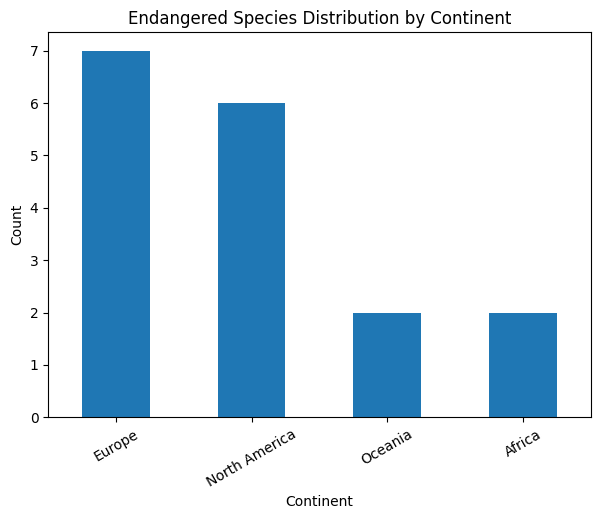

In [180]:
continent_counts = endangered_df["Continent"].value_counts()

continent_counts.plot(kind="bar", figsize=(7,5))
plt.title("Endangered Species Distribution by Continent")
plt.xlabel("Continent")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.show()

The analysis shows Europe has the highest proportion of species classified as endangered based on model-derived population trends. However, this result is strongly influenced by uneven data availability across regions. Europe and North America have more complete long-term biodiversity datasets, while other regions may be underrepresented due to limited historical monitoring.

Therefore, continental differences reflect both ecological trends and data coverage bias.

This project analysed long-term population data of multiple species to estimate extinction risk using machine learning and ecological trend features.

A risk classification model was developed using engineered features such as population change, growth ratio, and log-transformed decline metrics. Among multiple models tested, Random Forest and Gradient Boosting achieved the highest performance (~95.8% accuracy), indicating strong predictive capability.

Feature importance analysis revealed that relative population change (Growth_Ratio) and log-scaled change (Log_Change) were the most influential predictors of extinction risk. This aligns with ecological understanding that rate of decline is more informative than absolute population size.

Geographical analysis showed variation in endangered species distribution across countries and continents. However, these patterns are influenced not only by ecological reality but also by uneven biodiversity data collection and reporting intensity across regions.

biodiversity monitoring systems.

## Overall Takeaway

In this project, I used machine learning to explore ecological forecasting, but it also made me realize the limits of real-world environmental data.

I combined multiple approaches, including:

Time-series ecological analysis
Feature engineering
Classification modeling
Geographic biodiversity interpretation
Awareness of bias in scientific datasets

Overall, this wasn’t just about predicting trends — it was also about understanding how the data itself shapes what we think we’re seeing in nature.